In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load the stock data
data = pd.read_csv('/Users/alexanderdagher/Documents/new project/rand_forest/NVIDIA Stock Price History (5).csv')

# Clean and prepare the data
data.columns = [col.strip() for col in data.columns]
data['Date'] = pd.to_datetime(data['Date'], format='%m/%d/%Y')
data = data.sort_values('Date')


FileNotFoundError: [Errno 2] No such file or directory: '/Users/alexanderdagher/Documents/new project/rand_forest/NVIDIA Stock Price History (5).csv'

In [38]:
# Clean 'Vol.' column: convert M (Million) and B (Billion) to numeric
def parse_volume(vol):
    if 'M' in vol:
        return float(vol.replace('M', '').replace(',', '')) * 1e6
    elif 'B' in vol:
        return float(vol.replace('B', '').replace(',', '')) * 1e9
    else:
        return np.nan

data['Volume'] = data['Vol.'].apply(parse_volume)

# Feature Engineering using actual columns
data['5_MA'] = data['Price'].rolling(window=5).mean()
data['10_MA'] = data['Price'].rolling(window=10).mean()
data['5_Return'] = data['Price'].pct_change(periods=5)
data['10_Return'] = data['Price'].pct_change(periods=10)
data['Volatility'] = data['Price'].rolling(window=10).std()

# New Lag Features
data['Price_1d_lag'] = data['Price'].shift(1)
data['Price_2d_lag'] = data['Price'].shift(2)
data['5_Return_lag'] = data['5_Return'].shift(1)
data['10_Return_lag'] = data['10_Return'].shift(1)

In [39]:
# Shift the Price to create the prediction target (10 days ahead)
predict_days = 10
data['Target'] = data['Price'].shift(-predict_days)

# Drop rows with NaN values after feature engineering
data = data.dropna()

In [40]:
# Define features and target
features = ['Price', '5_MA', '10_MA', '5_Return', '10_Return', 'Volatility',
            'Price_1d_lag', 'Price_2d_lag', '5_Return_lag', '10_Return_lag']
X = data[features]
y = data['Target']

# Split the data (no shuffle because it's time series)
split = int(len(data) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [41]:
# Initialize and train Random Forest Regressor
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [42]:
# Predict on train and test sets
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

# Evaluate
train_mse = mean_squared_error(y_train, train_preds)
test_mse = mean_squared_error(y_test, test_preds)
train_r2 = r2_score(y_train, train_preds)
test_r2 = r2_score(y_test, test_preds)

print(f"Train MSE: {train_mse:.2f}, Train R2: {train_r2:.2f}")
print(f"Test MSE: {test_mse:.2f}, Test R2: {test_r2:.2f}")

Train MSE: 0.54, Train R2: 1.00
Test MSE: 1433.80, Test R2: -5.15


In [43]:
# Predict the next 10 future days properly
def predict_future(model, data, features, days=10):
    future_predictions = []
    recent_data = data.copy()
    
    for _ in range(days):
        last_row = recent_data.iloc[-1]
        recent_prices = recent_data['Price'].tail(10).tolist()

        # Build feature row
        new_features = {
            'Price': last_row['Price'],
            '5_MA': np.mean(recent_prices[-5:]),
            '10_MA': np.mean(recent_prices[-10:]),
            '5_Return': (recent_prices[-1] / recent_prices[-5]) - 1 if len(recent_prices) >= 5 else 0,
            '10_Return': (recent_prices[-1] / recent_prices[0]) - 1 if len(recent_prices) >= 10 else 0,
            'Volatility': np.std(recent_prices[-10:]),
            'Price_1d_lag': recent_prices[-1],
            'Price_2d_lag': recent_prices[-2] if len(recent_prices) >= 2 else recent_prices[-1],
            '5_Return_lag': (recent_prices[-1] / recent_prices[-5]) - 1 if len(recent_prices) >= 5 else 0,
            '10_Return_lag': (recent_prices[-1] / recent_prices[0]) - 1 if len(recent_prices) >= 10 else 0,
        }

        new_features_df = pd.DataFrame([new_features])
        pred_price = model.predict(new_features_df)[0]
        
        # Update with prediction
        new_row = last_row.copy()
        new_row['Price'] = pred_price
        recent_data = pd.concat([recent_data, pd.DataFrame([new_row])], ignore_index=True)
        future_predictions.append(pred_price)

    return future_predictions

future_prices = predict_future(model, data, features)
print("Future 10-day price predictions:")
print(future_prices)

Future 10-day price predictions:
[np.float64(92.01960000000014), np.float64(82.44285000000018), np.float64(82.30510000000017), np.float64(82.01050000000012), np.float64(81.97265000000012), np.float64(82.10905000000011), np.float64(82.8990500000001), np.float64(82.8864500000001), np.float64(83.26655000000008), np.float64(83.20865000000009)]


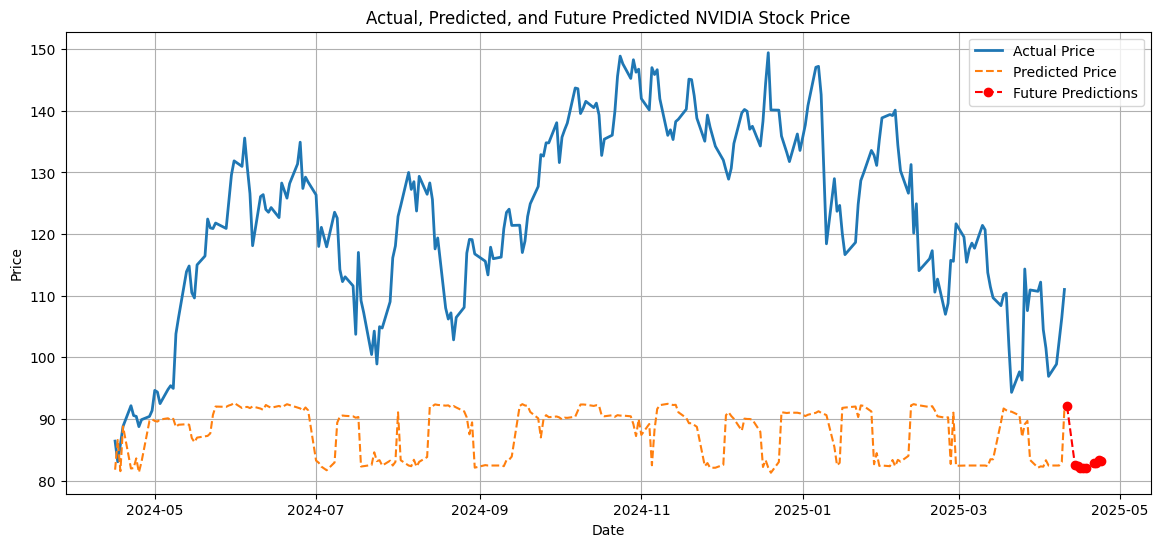

In [44]:
# Extend dates for future predictions
last_date = data['Date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=10, freq='B')

# Plot
plt.figure(figsize=(14,6))
plt.plot(data['Date'].iloc[split:], y_test, label='Actual Price', linewidth=2)
plt.plot(data['Date'].iloc[split:], test_preds, label='Predicted Price', linestyle='--')
plt.plot(future_dates, future_prices, label='Future Predictions', marker='o', linestyle='--', color='red')
plt.title('Actual, Predicted, and Future Predicted NVIDIA Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()